# Tutorial 4: Classification for Credit Risk — v6

## Risk prediction before approval and pricing

Build Logistic Regression, Random Forest and XGBoost models using information
available at application. Compare ranking (AUC) and classification errors, then
choose a screening threshold using training data only.

This tutorial adapts the earlier classification exercises. The supplied Imperial
source notebook describes the underlying credit dataset as **synthetic teaching
data**. The filename `lending_club_tutorial.csv` does not establish that it is real
LendingClub data. This example does not reproduce Bian's separate raw-data analysis.


**Scope:** Predict subsequent default using an application-time information set.
This dataset contains outcomes for recorded loans, not outcomes for every rejected
applicant. Its results illustrate classification and do not establish performance
for a live applicant population. No outcome horizon or application-time snapshot
is supplied; the timing assumptions below are part of the teaching setup.


## Part 1: Setup and Data Preparation

**Feature timing rules**

- Exclude `int_rate` and `grade`: final pricing and lender-assigned risk assessments
  are unavailable before approval and pricing.
- Retain `loan_amnt` as the **requested amount**, as confirmed by the dataset owner.
- Recompute `loan_percent_income = loan_amnt / annual_inc` from application inputs;
  it is a requested-loan-to-annual-income ratio, **not DTI**.
- Assume age, income, housing, employment, purpose, prior default and credit-history
  length refer to the application date. `prior_default` is historical credit-file
  information, not the outcome of this loan, and is not a FICO score.
- Select inputs by an explicit allowlist. Fit imputation, encoding and scaling on
  training data only. Keep identical allowed-input records in the same partition.

LR and RF keep their earlier model parameters. XGBoost parameters are selected by
five-fold training CV AUC. A separate XGBoost screening threshold is selected from
training out-of-fold scores to balance FP and FN relative to RF. Neither selection
uses the test labels. CV selection scores are optimistic; the test split is an
internal teaching check, not new external or temporal validation.


In [1]:
from pathlib import Path
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc, roc_auc_score)
from sklearn.model_selection import (GroupShuffleSplit, StratifiedGroupKFold,
    cross_val_predict)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)
output_dir = Path('figures')
output_dir.mkdir(exist_ok=True)
print('Libraries loaded. Prediction time: before approval and pricing.')


Libraries loaded. Prediction time: before approval and pricing.


In [2]:
# The filename is retained for compatibility; the source describes synthetic data.
data_path = Path('lending_club_tutorial.csv')
df = pd.read_csv(data_path)
print(f'Dataset shape: {df.shape}')
print(df.columns.tolist())


Dataset shape: (32572, 12)
['default', 'loan_amnt', 'int_rate', 'grade', 'purpose', 'loan_percent_income', 'person_age', 'annual_inc', 'home_ownership', 'emp_length', 'prior_default', 'credit_history']


In [3]:
# =============================================================================
# Explore the data
# =============================================================================

# Look at the first few rows
print("First 5 rows:")
df.head()

First 5 rows:
   default  loan_amnt  int_rate  ... emp_length prior_default  credit_history
0        1      15000     16.32  ...        8.0             1               4
1        1      25000     15.95  ...        3.0             1               6
2        0       5000      7.49  ...        0.0             0               3
3        0      10000     15.62  ...       14.0             1               6
4        0       4500      6.54  ...        4.0             0               6

[5 rows x 12 columns]


In [4]:
# =============================================================================
# Understand the target variable
# =============================================================================

# 'default' is our target: 1 = borrower defaulted, 0 = loan repaid

print("Target variable distribution:")
print(df['default'].value_counts())
print(f"\nDefault rate: {df['default'].mean():.1%}")
print(f"  - Non-defaults: {(df['default']==0).sum():,}")
print(f"  - Defaults: {(df['default']==1).sum():,}")

Target variable distribution:
default
0    25465
1     7107
Name: count, dtype: int64

Default rate: 21.8%
  - Non-defaults: 25,465
  - Defaults: 7,107


In [5]:
# Eight recorded application inputs plus one derived application-time ratio.
numeric_cols = ['person_age', 'annual_inc', 'emp_length', 'prior_default',
                'credit_history', 'loan_amnt', 'loan_percent_income']
categorical_cols = ['home_ownership', 'purpose']
input_cols = numeric_cols + categorical_cols
raw_cols = [name for name in input_cols if name != 'loan_percent_income']
X = df.loc[:, raw_cols].copy()
income = pd.to_numeric(X['annual_inc'], errors='raise')
X['loan_percent_income'] = X['loan_amnt'].div(income.where(income > 0))
X = X[input_cols].replace([np.inf, -np.inf], np.nan)
y = df['default'].astype(int)
assert not {'default', 'int_rate', 'grade'}.intersection(X.columns)
assert X.columns.tolist() == input_cols
print('Raw model inputs:', X.columns.tolist())
print('Excluded: int_rate, grade. Target only: default.')
X.describe().round(3)


Raw model inputs: ['person_age', 'annual_inc', 'emp_length', 'prior_default', 'credit_history', 'loan_amnt', 'loan_percent_income', 'home_ownership', 'purpose']
Excluded: int_rate, grade. Target only: default.
       person_age   annual_inc  ...  loan_amnt  loan_percent_income
count   32572.000    32572.000  ...   32572.00            32572.000
mean       27.715    65878.879  ...    9588.10                0.171
std         6.186    52532.795  ...    6320.42                0.107
min        20.000     4000.000  ...     500.00                0.001
25%        23.000    38500.000  ...    5000.00                0.090
50%        26.000    55000.000  ...    8000.00                0.148
75%        30.000    79200.000  ...   12200.00                0.229
max        80.000  2039784.000  ...   35000.00                0.830

[8 rows x 7 columns]


In [6]:
# Define preprocessing now; fit it only after splitting.
# This function also creates a fresh transformer for every CV fold.
def make_preprocessor():
    return ColumnTransformer([
        ('numeric', SimpleImputer(strategy='median'), numeric_cols),
        ('categorical', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(drop='first', handle_unknown='ignore',
                                      sparse_output=False)),
        ]), categorical_cols),
    ], remainder='drop', sparse_threshold=0)


In [7]:
print('Missing values in allowed inputs:')
print(X.isna().sum())
# Missing values are filled using training-fold statistics, never test statistics.


Missing values in allowed inputs:
person_age             0
annual_inc             0
emp_length             0
prior_default          0
credit_history         0
loan_amnt              0
loan_percent_income    0
home_ownership         0
purpose                0
dtype: int64


In [8]:
# Group identical application records to prevent overlap across partitions.
# These groups do not use the target, interest rate or grade.
groups = pd.util.hash_pandas_object(X, index=False).to_numpy()
train_idx, test_idx = next(GroupShuffleSplit(
    n_splits=1, test_size=0.30, random_state=42).split(X, y, groups))
assert not set(groups[train_idx]).intersection(groups[test_idx])
X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
train_groups = groups[train_idx]
print(f'Train: {len(train_idx):,}; test: {len(test_idx):,}')
print(f'Default rates: train={y_train.mean():.2%}; test={y_test.mean():.2%}')


Train: 22,795; test: 9,777
Default rates: train=22.13%; test=21.09%


In [9]:
preprocess = make_preprocessor()
X_train = preprocess.fit_transform(X_train_raw)
X_test = preprocess.transform(X_test_raw)
feature_names = preprocess.get_feature_names_out().tolist()
assert not any('grade' in name or 'int_rate' in name for name in feature_names)
assert X_train.shape[1] == X_test.shape[1] == len(feature_names)
print(f'Encoded features ({len(feature_names)}):')
print(feature_names)


Encoded features (15):
['numeric__person_age', 'numeric__annual_inc', 'numeric__emp_length', 'numeric__prior_default', 'numeric__credit_history', 'numeric__loan_amnt', 'numeric__loan_percent_income', 'categorical__home_ownership_OTHER', 'categorical__home_ownership_OWN', 'categorical__home_ownership_RENT', 'categorical__purpose_EDUCATION', 'categorical__purpose_HOMEIMPROVEMENT', 'categorical__purpose_MEDICAL', 'categorical__purpose_PERSONAL', 'categorical__purpose_VENTURE']


In [10]:
# Scale the encoded features for LR only, using the training data.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Part 2: Train Classification Models

1. Logistic Regression: original baseline parameters, retrained on the new inputs.
2. Random Forest: original baseline parameters, retrained on the same inputs.
3. XGBoost: parameters frozen after a search using the training set only.

All models see the same information. Weighted model scores are useful for ranking
and thresholding but should not be interpreted directly as calibrated PDs.


In [11]:
# Same baseline: default L2 regularization, C=1, balanced weights, seed=42.
logreg = LogisticRegression(C=1.0, class_weight='balanced',
                            max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
print('Logistic Regression fitted.')


Logistic Regression fitted.


In [12]:
# Same RF baseline; n_jobs only controls CPU use.
rf = RandomForestClassifier(n_estimators=200, max_depth=10,
    min_samples_leaf=20, class_weight='balanced', random_state=42, n_jobs=2)
rf.fit(X_train, y_train)
print('Random Forest fitted.')


Random Forest fitted.


In [13]:
# Frozen by training CV AUC; do not retune using the test results below.
xgb_params = {'n_estimators': 1200, 'learning_rate': 0.07415805824053914, 'max_depth': 3, 'min_child_weight': 4.369944120084866, 'subsample': 0.8414902506684043, 'colsample_bytree': 0.8702050470142777, 'reg_alpha': 0.042260114069201264, 'reg_lambda': 6.075700989710291, 'gamma': 0.008911743386941978, 'scale_pos_weight': 2.588304190635817}
xgb_threshold = 0.4549999999999999
expected_data_sha256 = '4dbeb2880e9a0362bf4be07eb025cc63b694c17b999857a6a015c7f691a2b61f'
assert hashlib.sha256(data_path.read_bytes()).hexdigest() == expected_data_sha256, \
    'Dataset changed: rerun tune_preapproval_credit_risk.py before using these results.'
xgb = XGBClassifier(**xgb_params, objective='binary:logistic', eval_metric='auc',
    tree_method='hist', random_state=42, n_jobs=2, verbosity=0)
xgb.fit(X_train, y_train)
print('XGBoost fitted. Training-selected screening threshold:', xgb_threshold)


XGBoost fitted. Training-selected screening threshold: 0.4549999999999999


In [14]:
y_prob_logreg = logreg.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred_logreg = (y_prob_logreg >= 0.50).astype(int)
y_pred_rf = (y_prob_rf >= 0.50).astype(int)
y_pred_xgb = (y_prob_xgb >= 0.50).astype(int)
y_pred_xgb_screening = (y_prob_xgb >= xgb_threshold).astype(int)
print('Predictions generated. Main comparison uses 0.50 for every model.')


Predictions generated. Main comparison uses 0.50 for every model.


## Part 3: The Confusion Matrix

Rows are actual outcomes; columns are predicted outcomes. Top right is a false
positive (a non-defaulter flagged as risky); bottom left is a false negative
(a missed default). The first figure uses 0.50 for all models. The second displays
the frozen training-selected XGBoost screening threshold; LR and RF stay at 0.50.
Threshold changes do not change AUC.


PNG saved to: J:\uodrive\OneDrive - University of Ottawa\Files\Teaching\ADM 4356 Fall 2026\Machine learning for credit risk\imperial\figures\confusion_matrices_v6_050_600dpi.png
PDF saved to: J:\uodrive\OneDrive - University of Ottawa\Files\Teaching\ADM 4356 Fall 2026\Machine learning for credit risk\imperial\figures\confusion_matrices_v6_050.pdf
PNG saved to: J:\uodrive\OneDrive - University of Ottawa\Files\Teaching\ADM 4356 Fall 2026\Machine learning for credit risk\imperial\figures\confusion_matrices_v6_screening_600dpi.png
PDF saved to: J:\uodrive\OneDrive - University of Ottawa\Files\Teaching\ADM 4356 Fall 2026\Machine learning for credit risk\imperial\figures\confusion_matrices_v6_screening.pdf


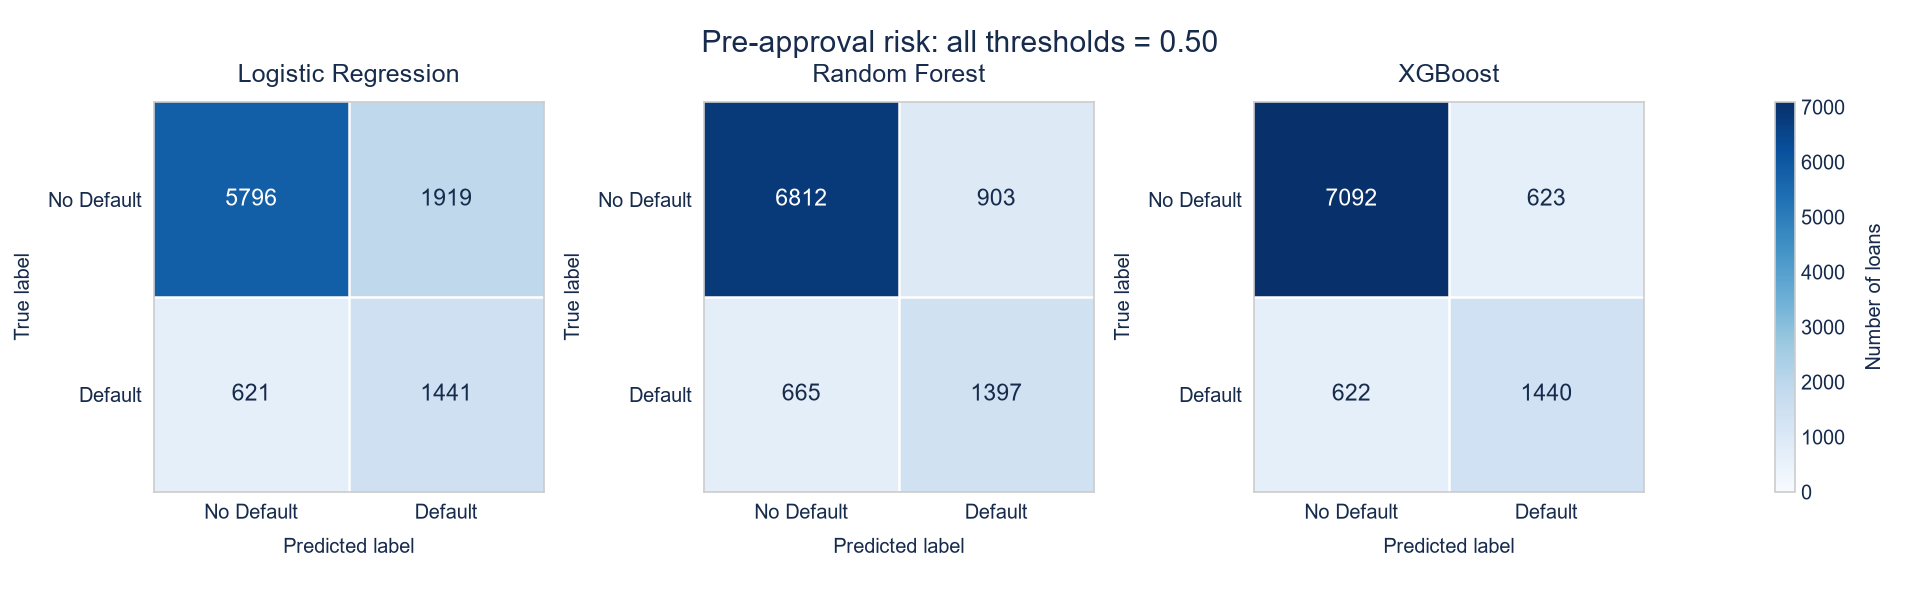

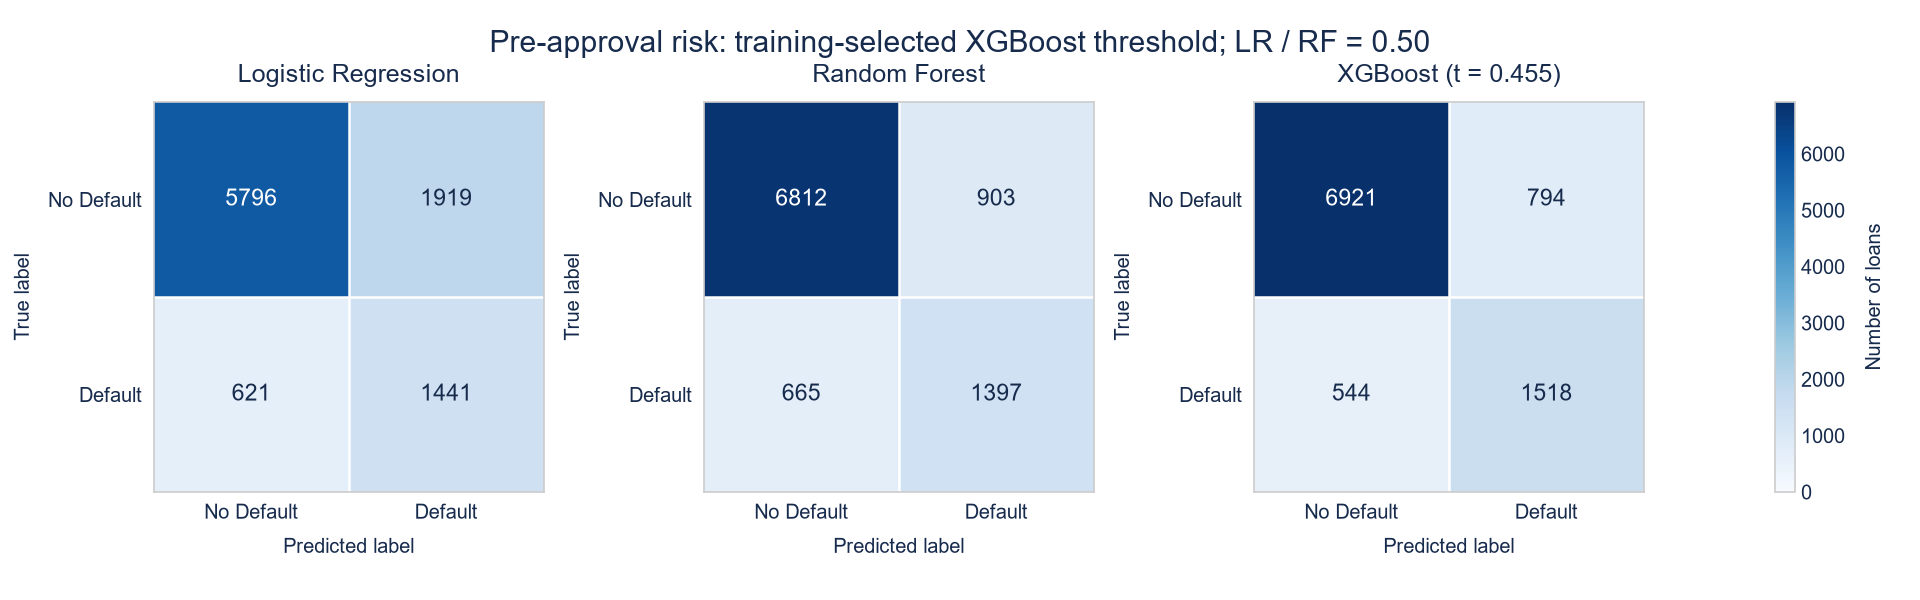

In [15]:
# Fixed fourth column for one shared colorbar; white separators at category edges.
def plot_confusion_comparison(xgb_prediction, xgb_label, figure_title, stem):
    model_predictions = [
        ('Logistic Regression', y_pred_logreg),
        ('Random Forest', y_pred_rf),
        (xgb_label, xgb_prediction),
    ]
    matrices = [confusion_matrix(y_test, pred, labels=[0, 1])
                for _, pred in model_predictions]
    max_count = max(matrix.max() for matrix in matrices)
    output_dir = Path('figures')
    output_dir.mkdir(parents=True, exist_ok=True)

    # A dedicated fourth column reserves space for the shared colorbar.
    # Avoid tight_layout(): it can move the model panels onto a shared colorbar.
    with plt.rc_context({
        'figure.facecolor': 'white', 'axes.facecolor': 'white',
        'savefig.facecolor': 'white', 'savefig.transparent': False,
        'text.color': '#172B4D', 'axes.labelcolor': '#172B4D',
        'xtick.color': '#172B4D', 'ytick.color': '#172B4D',
        'font.size': 12, 'axes.grid': False,
        'pdf.fonttype': 42,
    }):
        fig = plt.figure(figsize=(16, 5), dpi=160)
        grid = fig.add_gridspec(
            1, 4, width_ratios=[1, 1, 1, 0.045],
            left=0.065, right=0.935, bottom=0.18, top=0.83, wspace=0.30,
        )
        axes = [fig.add_subplot(grid[0, i]) for i in range(3)]
        colorbar_ax = fig.add_subplot(grid[0, 3])

        for ax, (name, _), matrix in zip(axes, model_predictions, matrices):
            display = ConfusionMatrixDisplay(
                confusion_matrix=matrix, display_labels=['No Default', 'Default'],
            )
            display.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
            display.im_.set_clim(0, max_count)
            for value, text_label in zip(matrix.ravel(), display.text_.ravel()):
                text_label.set_color('white' if value > max_count / 2 else '#172B4D')
                text_label.set_fontsize(14)
            ax.set_title(name, fontsize=15, pad=12)
            ax.set_xlabel('Predicted label', fontsize=12, labelpad=9)
            ax.set_ylabel('True label', fontsize=12, labelpad=9)
            ax.grid(False, which='both')
            ax.axvline(0.5, color='white', linewidth=1.5)
            ax.axhline(0.5, color='white', linewidth=1.5)
            ax.tick_params(axis='both', which='both', length=0, pad=7)

        colorbar = fig.colorbar(display.im_, cax=colorbar_ax)
        colorbar.set_label('Number of loans', labelpad=12)
        fig.suptitle(figure_title, fontsize=18, y=0.95)

        # PNG: exactly 9600 x 3000 pixels at 600 dpi; PDF keeps text/lines as vectors.
        png_path = output_dir / f'{stem}_600dpi.png'
        pdf_path = output_dir / f'{stem}.pdf'
        fig.savefig(png_path, dpi=600, facecolor='white', transparent=False)
        fig.savefig(pdf_path, dpi=600, facecolor='white', transparent=False)
        plt.show()

    print(f'PNG saved to: {png_path.resolve()}')
    print(f'PDF saved to: {pdf_path.resolve()}')


plot_confusion_comparison(y_pred_xgb, 'XGBoost',
    'Pre-approval risk: all thresholds = 0.50', 'confusion_matrices_v6_050')
plot_confusion_comparison(y_pred_xgb_screening, f'XGBoost (t = {xgb_threshold:.3f})',
    'Pre-approval risk: training-selected XGBoost threshold; LR / RF = 0.50',
    'confusion_matrices_v6_screening')


In [16]:
TN, FP, FN, TP = confusion_matrix(y_test, y_pred_logreg, labels=[0, 1]).ravel()
print(f'LR: TN={TN:,}, FP={FP:,}, FN={FN:,}, TP={TP:,}')
print('FP: non-defaulter flagged as risky. FN: missed default.')


LR: TN=5,796, FP=1,919, FN=621, TP=1,441
FP: non-defaulter flagged as risky. FN: missed default.


---

## Part 4: Evaluation Metrics

### 4.1 Precision, Recall, and F1 Score

In [17]:
# =============================================================================
# Calculate and understand key metrics
# =============================================================================

# PRECISION: Of all loans we flagged as "default", what % actually defaulted?
# Precision = TP / (TP + FP)
# Interpretation: How reliable are our "deny" decisions?
precision = TP / (TP + FP) if (TP + FP) > 0 else 0

# RECALL (Sensitivity): Of all actual defaults, what % did we catch?
# Recall = TP / (TP + FN)  
# Interpretation: How many defaults did we miss?
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

# F1 SCORE: Harmonic mean of precision and recall
# F1 = 2 * (Precision * Recall) / (Precision + Recall)
# Interpretation: Single metric balancing both
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# ACCURACY: Overall correct predictions (can be misleading!)
accuracy = (TP + TN) / (TP + TN + FP + FN)

print("Logistic Regression Metrics (at threshold = 0.5):")
print("="*50)
print(f"Precision: {precision:.3f} ({precision*100:.1f}%)")
print(f"  → Of loans flagged as risky, {precision*100:.1f}% actually defaulted")
print(f"")
print(f"Recall:    {recall:.3f} ({recall*100:.1f}%)")
print(f"  → We caught {recall*100:.1f}% of all defaults")
print(f"")
print(f"F1 Score:  {f1:.3f}")
print(f"")
print(f"Accuracy:  {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"  ⚠️ Accuracy can be misleading with imbalanced data!")

Logistic Regression Metrics (at threshold = 0.5):
Precision: 0.429 (42.9%)
  → Of loans flagged as risky, 42.9% actually defaulted

Recall:    0.699 (69.9%)
  → We caught 69.9% of all defaults

F1 Score:  0.532

Accuracy:  0.740 (74.0%)
  ⚠️ Accuracy can be misleading with imbalanced data!


In [18]:
# =============================================================================
# Compare all models using classification_report
# =============================================================================

print("Model Comparison (at threshold = 0.5):")
print("="*60)

for name, y_pred in [
    ('Logistic Regression', y_pred_logreg),
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb)
]:
    print(f"\n{name}:")
    print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

Model Comparison (at threshold = 0.5):

Logistic Regression:
              precision    recall  f1-score   support

  No Default       0.90      0.75      0.82      7715
     Default       0.43      0.70      0.53      2062

    accuracy                           0.74      9777
   macro avg       0.67      0.73      0.68      9777
weighted avg       0.80      0.74      0.76      9777


Random Forest:
              precision    recall  f1-score   support

  No Default       0.91      0.88      0.90      7715
     Default       0.61      0.68      0.64      2062

    accuracy                           0.84      9777
   macro avg       0.76      0.78      0.77      9777
weighted avg       0.85      0.84      0.84      9777


XGBoost:
              precision    recall  f1-score   support

  No Default       0.92      0.92      0.92      7715
     Default       0.70      0.70      0.70      2062

    accuracy                           0.87      9777
   macro avg       0.81      0.81      0.

### 4.2 ROC Curve and AUC


💡 AUC Interpretation:
   AUC = probability that model ranks a random defaulter higher than a random non-defaulter
   Higher AUC = better ranking ability across all thresholds


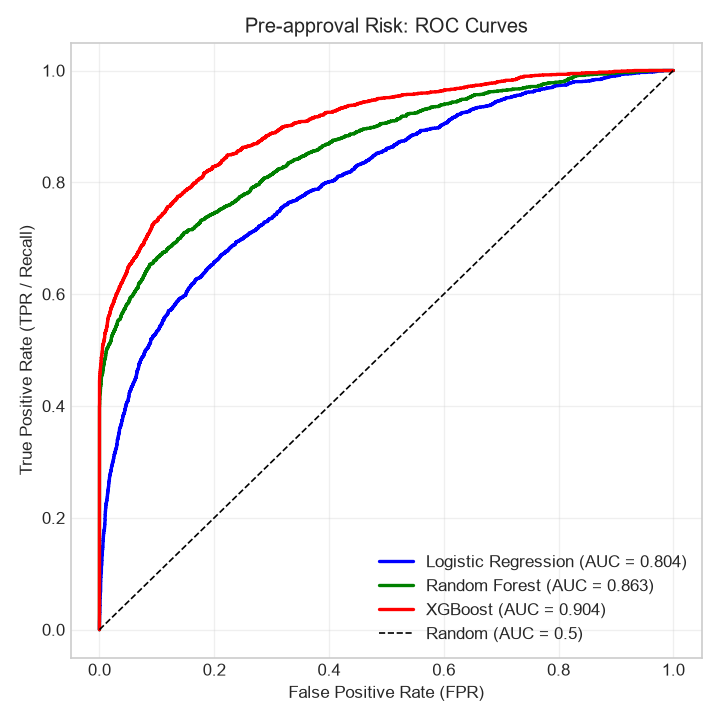

In [19]:
# =============================================================================
# Plot ROC curves for all models
# =============================================================================

# ROC curve shows the trade-off between:
# - True Positive Rate (TPR) = Recall = TP / (TP + FN)
# - False Positive Rate (FPR) = FP / (FP + TN)
#
# As we lower the threshold:
# - We predict "default" more often
# - TPR increases (catch more defaults)
# - FPR also increases (more false alarms)

plt.figure(figsize=(6, 6))

# Calculate and plot ROC curve for each model
for name, y_prob, color in [
    ('Logistic Regression', y_prob_logreg, 'blue'),
    ('Random Forest', y_prob_rf, 'green'),
    ('XGBoost', y_prob_xgb, 'red')
]:
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.plot(fpr, tpr, color=color, linewidth=2, 
             label=f'{name} (AUC = {roc_auc:.3f})')

# Plot diagonal (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR / Recall)')
plt.title('Pre-approval Risk: ROC Curves')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / 'roc_curves_v6_600dpi.png', dpi=600, facecolor='white')
plt.savefig(output_dir / 'roc_curves_v6.pdf', facecolor='white')
plt.show()

print("\n💡 AUC Interpretation:")
print("   AUC = probability that model ranks a random defaulter higher than a random non-defaulter")
print("   Higher AUC = better ranking ability across all thresholds")


### 🤖 AI Prompt Exercise 1: Interpret the Metrics

**Task:** Ask an AI to help interpret your evaluation results.

**Copy this prompt (fill in your values):**

```
I built a credit risk model with these results at threshold=0.5:

- Precision: [YOUR VALUE]
- Recall: [YOUR VALUE]
- AUC: [YOUR VALUE]

Questions:
1. If precision is 35%, what does that mean for my business decisions?
2. If recall is 65%, what percentage of defaults am I missing?
3. Is my AUC score good, average, or poor for credit risk?

Explain in business terms (4-5 sentences).
```

**Write the key insights:**

*Your notes:*



## Part 5: Threshold Selection Using Training Data

AUC evaluates ranking. An operating threshold trades off false alarms and missed
defaults. The 0.50 threshold is a reference point, not necessarily the best business
choice. Here we illustrate a **different objective** from the balanced-error figure:
minimize an assumed cost of FP and FN, using training out-of-fold predictions only.
The cost values are teaching assumptions, not measured losses or quoted loan terms.


In [20]:
COST_FP = 500   # Illustrative cost units for a non-defaulter flagged as risky.
COST_FN = 5000  # Illustrative cost units for a missed default.
print(f'Illustrative costs: FP={COST_FP}, FN={COST_FN}; ratio={COST_FN/COST_FP:.0f}')


Illustrative costs: FP=500, FN=5000; ratio=10


In [21]:
# =============================================================================
# Calculate total cost at different thresholds
# =============================================================================

def calculate_cost_at_threshold(y_true, y_prob, threshold, cost_fp, cost_fn):
    """
    Calculate total cost of errors at a given threshold.

    Parameters:
    -----------
    y_true : array, actual labels (0 or 1)
    y_prob : array, predicted probabilities
    threshold : float, classification threshold
    cost_fp : float, cost of false positive
    cost_fn : float, cost of false negative

    Returns:
    --------
    dict with FP count, FN count, total cost, and metrics
    """
    # Make predictions at this threshold
    y_pred = (y_prob >= threshold).astype(int)

    # Get confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()

    # Calculate total cost
    total_cost = (FP * cost_fp) + (FN * cost_fn)

    # Calculate metrics
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0

    return {
        'threshold': threshold,
        'FP': FP,
        'FN': FN,
        'total_cost': total_cost,
        'precision': precision,
        'recall': recall
    }


In [22]:
# Each training prediction comes from a model that did not fit that row or group.
# The preprocessing is also fitted separately inside each fold.
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
cv_splits = list(cv.split(X_train_raw, y_train, train_groups))
cv_model = Pipeline([
    ('preprocess', make_preprocessor()),
    ('model', XGBClassifier(**xgb_params, objective='binary:logistic',
        eval_metric='auc', tree_method='hist', random_state=42, n_jobs=2, verbosity=0)),
])
y_prob_train_oof = cross_val_predict(cv_model, X_train_raw, y_train,
    cv=cv_splits, method='predict_proba', n_jobs=1)[:, 1]
results_df = pd.DataFrame([
    calculate_cost_at_threshold(y_train, y_prob_train_oof, t, COST_FP, COST_FN)
    for t in np.linspace(0.05, 0.95, 181)
])
optimal_idx = results_df['total_cost'].idxmin()
optimal_threshold = float(results_df.loc[optimal_idx, 'threshold'])
optimal_cost = float(results_df.loc[optimal_idx, 'total_cost'])
print(f'Training-selected cost threshold: {optimal_threshold:.3f}')
print('Selection used training OOF scores only; these selection scores are optimistic.')


Training-selected cost threshold: 0.190
Selection used training OOF scores only; these selection scores are optimistic.



💡 Key insight: Lower threshold catches more defaults (fewer FN)
   but also denies more good borrowers (more FP)


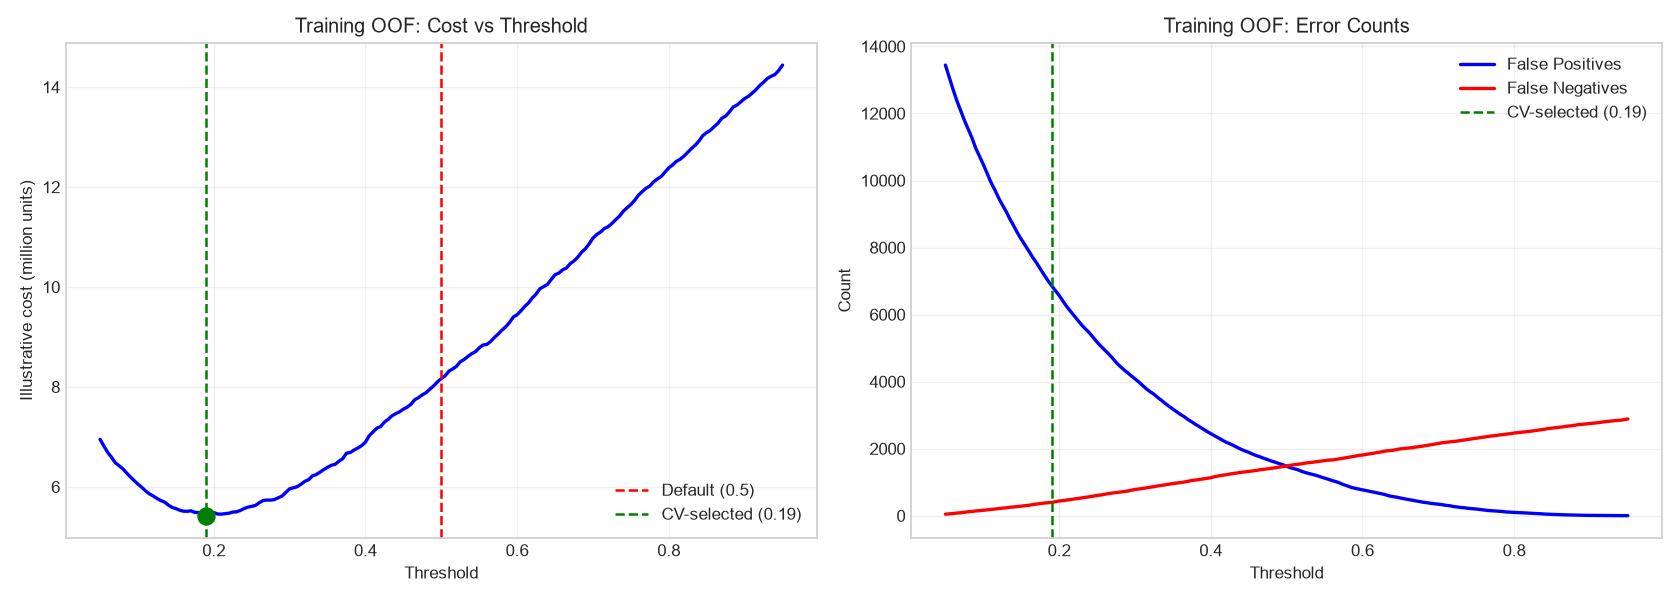

In [23]:
# =============================================================================
# Visualize cost vs threshold
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Total cost vs threshold
ax1 = axes[0]
ax1.plot(results_df['threshold'], results_df['total_cost']/1e6, 'b-', linewidth=2)
ax1.axvline(x=0.5, color='red', linestyle='--', label='Default (0.5)')
ax1.axvline(x=optimal_threshold, color='green', linestyle='--', label=f'CV-selected ({optimal_threshold:.2f})')
ax1.scatter([optimal_threshold], [optimal_cost/1e6], color='green', s=100, zorder=5)
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Illustrative cost (million units)')
ax1.set_title('Training OOF: Cost vs Threshold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot: FP and FN vs threshold
ax2 = axes[1]
ax2.plot(results_df['threshold'], results_df['FP'], 'b-', linewidth=2, label='False Positives')
ax2.plot(results_df['threshold'], results_df['FN'], 'r-', linewidth=2, label='False Negatives')
ax2.axvline(x=optimal_threshold, color='green', linestyle='--', label=f'CV-selected ({optimal_threshold:.2f})')
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Count')
ax2.set_title('Training OOF: Error Counts')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'threshold_cost_v6_600dpi.png', dpi=600, facecolor='white')
plt.savefig(output_dir / 'threshold_cost_v6.pdf', facecolor='white')
plt.show()

print("\n💡 Key insight: Lower threshold catches more defaults (fewer FN)")
print("   but also denies more good borrowers (more FP)")


In [24]:
# Evaluate frozen thresholds; do not choose between them using these test results.
comparison = pd.DataFrame([
    {'Policy': label, **calculate_cost_at_threshold(
        y_test, y_prob_xgb, threshold, COST_FP, COST_FN)}
    for label, threshold in [('Reference', 0.50),
                              ('Balanced errors (training)', xgb_threshold),
                              ('Cost objective (training)', optimal_threshold)]
])
print('Test results at thresholds selected before test evaluation:')
print(comparison.to_string(index=False))


Test results at thresholds selected before test evaluation:
                    Policy  threshold   FP  FN  total_cost  precision   recall
                 Reference      0.500  623 622     3421500   0.698013 0.698351
Balanced errors (training)      0.455  794 544     3117000   0.656574 0.736178
 Cost objective (training)      0.190 3018 160     2309000   0.386585 0.922405


### AI Prompt Exercise 2: Explain Threshold Selection

Explain how changing a risk-score threshold affects FP and FN. Use the displayed
reference and training-selected results. Why must threshold selection use training
or validation data, rather than the final test set? Why can a cost-minimizing
threshold differ from one that balances FP and FN relative to another model?


*Your notes:*



## Part 6: From Risk Scores to Application Screening

This is a screening illustration before final approval or pricing. High scores
trigger further review. The model does not directly set interest rates or estimate
portfolio losses: that requires calibrated PDs, an outcome horizon and additional
assumptions about exposure, recovery, costs and loan terms.


In [25]:
def screening_action(risk_score, threshold):
    return 'Further risk review' if risk_score >= threshold else 'Standard review'


In [26]:
decisions_df = pd.DataFrame({
    'actual_default': y_test.to_numpy(),
    'risk_score': y_prob_xgb,
    'action': [screening_action(p, xgb_threshold) for p in y_prob_xgb],
})
decision_summary = decisions_df.groupby('action').agg(
    Count=('actual_default', 'size'),
    Defaults=('actual_default', 'sum'),
    Observed_default_rate=('actual_default', 'mean'),
)
print(decision_summary.to_string())


                     Count  Defaults  Observed_default_rate
action                                                     
Further risk review   2312      1518               0.656574
Standard review       7465       544               0.072873


In [27]:
# Requested amount is available, but it is not an approved exposure or a loss.
decisions_df['requested_amount'] = X_test_raw['loan_amnt'].to_numpy()
print(decisions_df.groupby('action')['requested_amount'].agg(['count', 'sum', 'mean']))
print('Class-weighted risk scores are not automatically calibrated probabilities of default.')


                     count       sum          mean
action                                            
Further risk review   2312  24363975  10538.051471
Standard review       7465  68664800   9198.231748
Class-weighted risk scores are not automatically calibrated probabilities of default.


### AI Prompt Exercise 3: Check the Information Set

Explain why `int_rate` and `grade` are excluded from a pre-approval, pre-pricing
model. Why can the requested amount be retained? Explain why the requested-loan-to-
income ratio is not DTI, and why historical default is not a FICO score. What extra
data and validation would be needed to use these scores for actual pricing?


In [28]:
# Paste AI-generated code here:


---

## Part 7: Key Takeaways

### Summary

In [29]:
rows = []
for name, scores, threshold in [
    ('Logistic Regression', y_prob_logreg, 0.50),
    ('Random Forest', y_prob_rf, 0.50),
    ('XGBoost (0.50)', y_prob_xgb, 0.50),
    ('XGBoost (training-selected)', y_prob_xgb, xgb_threshold),
]:
    tn, fp, fn, tp = confusion_matrix(y_test, scores >= threshold, labels=[0, 1]).ravel()
    rows.append({'Model': name, 'AUC': roc_auc_score(y_test, scores),
        'Threshold': threshold, 'FP': fp, 'FN': fn,
        'Error rate': (fp + fn) / len(y_test)})
final_comparison = pd.DataFrame(rows)
print(final_comparison.to_string(index=False))


                      Model      AUC  Threshold   FP  FN  Error rate
        Logistic Regression 0.803703      0.500 1919 621    0.259793
              Random Forest 0.863117      0.500  903 665    0.160376
             XGBoost (0.50) 0.903643      0.500  623 622    0.127340
XGBoost (training-selected) 0.903643      0.455  794 544    0.136852


### Key Lessons

1. Define prediction time before choosing features. Pricing and lender-assigned
   grade cannot be inputs to a model operating before those decisions.
2. All models use the same allowed information. LR and RF remain fixed baselines;
   XGBoost receives a training-only parameter search. This is not a comparison of
   equally tuned algorithms.
3. AUC measures ranking; FP and FN also depend on the operating threshold.
4. Choose parameters and thresholds inside the training data, then evaluate the
   frozen choices. Neither better AUC nor lower errors on both sides is guaranteed.
5. Weighted scores need calibration checks before interpretation as PDs. This
   synthetic loan sample does not establish live applicant or pricing performance.
